# 02 - Envelope (IDP) vs classical time-domain

The instantaneous dynamic phasor (IDP) tracks a circuit's slowly-varying
*envelope* on a single carrier shift, instead of stepping through every carrier
cycle the way a classical time-domain (TD) solve does. For a lightly-damped
resonant circuit driven at its carrier, that is a large amount of saved work.

This notebook runs the **same** series-RLC netlist twice - `mode="idp"` and
`mode="td"` - overlays the two outputs, and measures how the IDP speedup grows
with the simulated window. Everything comes from real solves; the timing
numbers are machine-dependent and reported as such.

**Corresponds to the paper:** the IDP-vs-classical agreement and the speedup-grows-with-duration mechanism behind the paper's IEEE-network speedups (Abstract; Table IV).


In [1]:
%matplotlib inline
%config InlineBackend.figure_format = "retina"
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import dpspice
from dpspice.plotting import use_style, PALETTE, style_table
use_style()

# Series-RLC resonance ~ 580 krad/s.
F = 580e3 / (2 * np.pi)

def rlc_netlist(n_cycles):
    return (f"V1 in 0 SINE(0 1 {F:.6g})\n"
            f"R1 in n2 3.0\nL1 n2 out 100.04u\nC1 out 0 30.07n\n"
            f"R2 out 0 2k\n.tran 0 {n_cycles / F:.6g}\n.end\n")

def vout(result):
    w = next(w for w in result.waveforms if w.name.lower() == "v(out)")
    return np.asarray(w.t, float), np.asarray(w.v, float)


## Same circuit, two solvers - do they agree?

We overlay V(out) from the IDP envelope and the full TD solve over a short
window, then quantify the agreement with an NRMSE on a shared time grid.

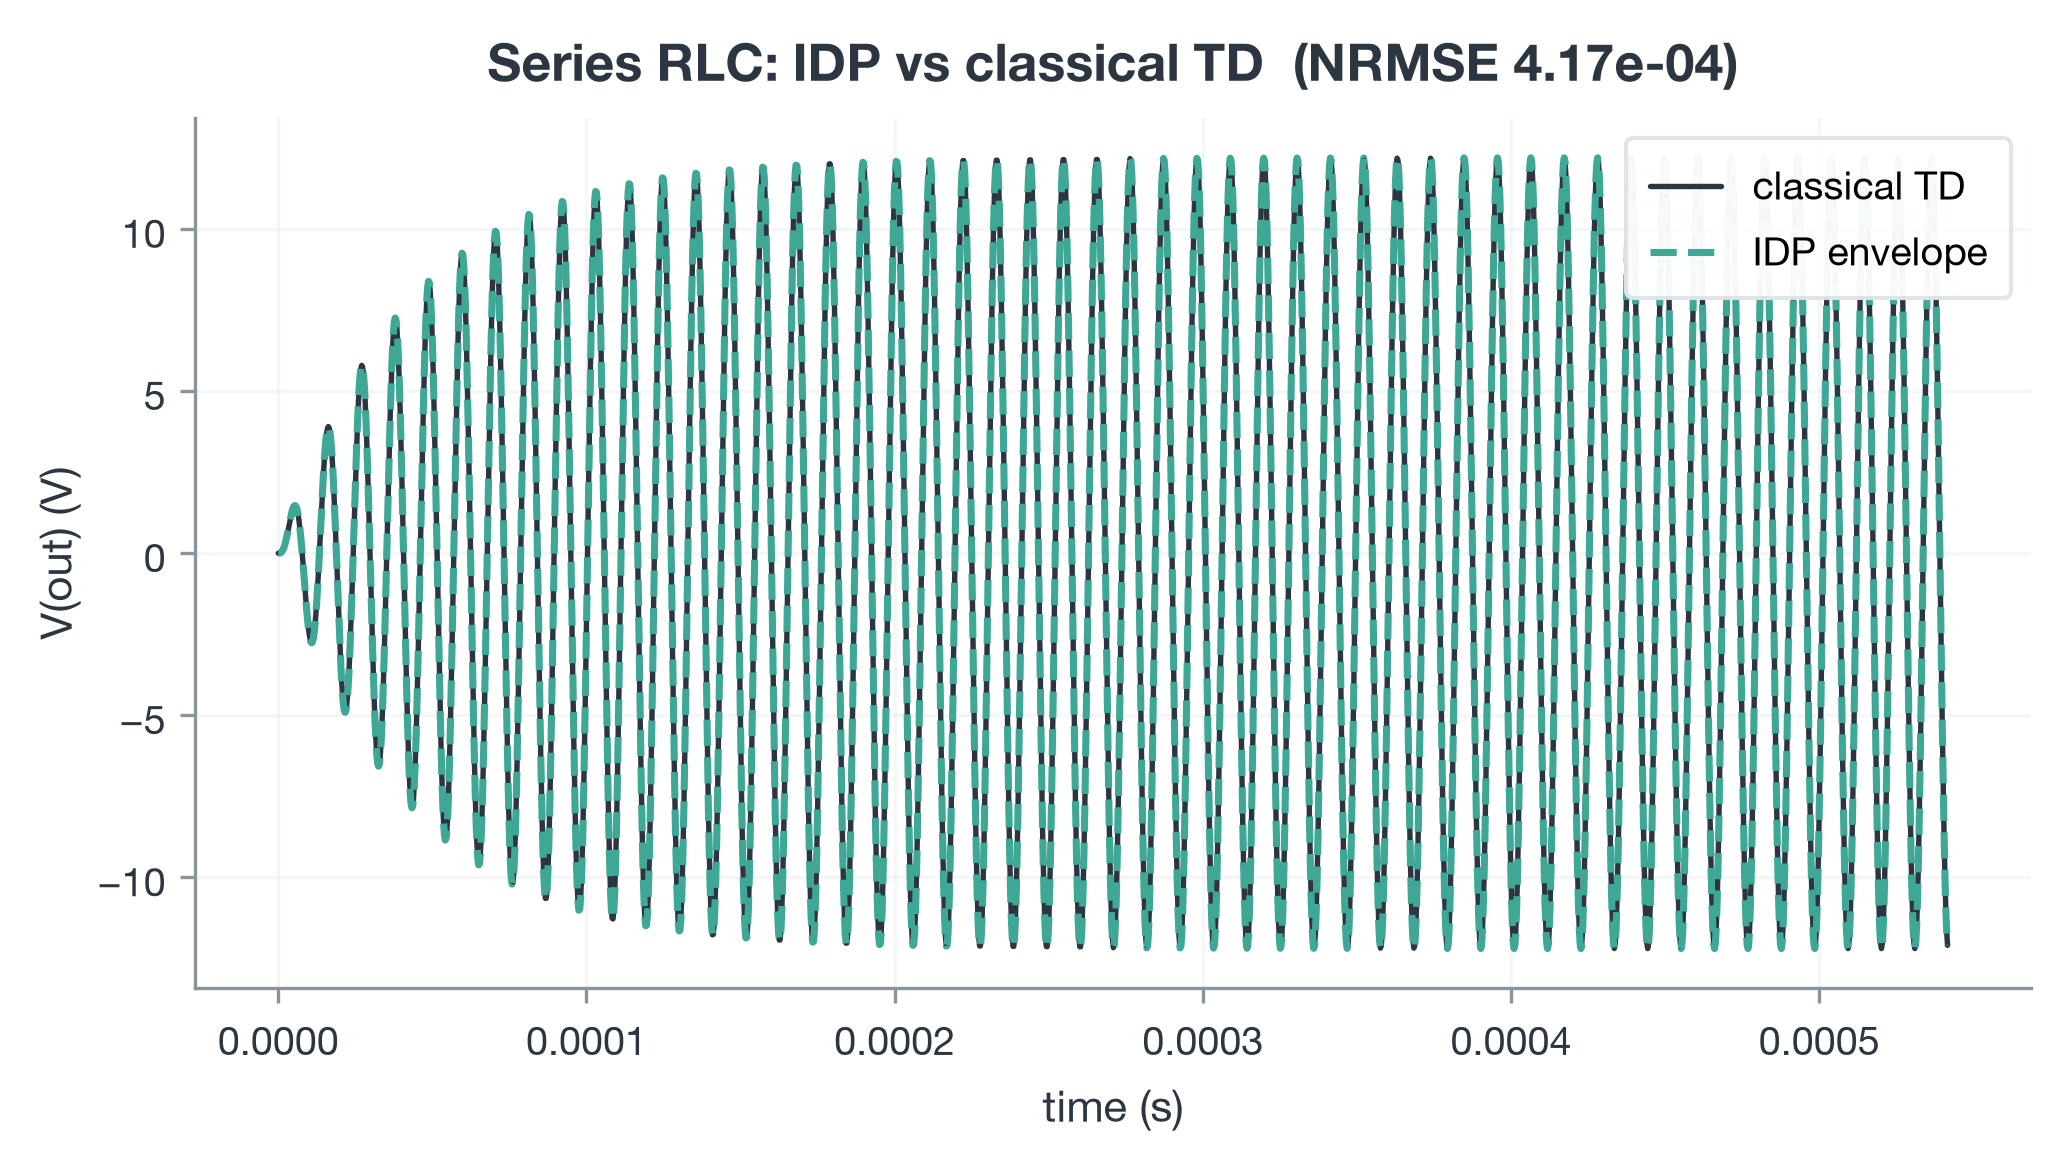

In [2]:
nl = rlc_netlist(50)
ri = dpspice.load(nl).run(mode="idp")
rt = dpspice.load(nl).run(mode="td")

ti, vi = vout(ri)
tt, vt = vout(rt)

# NRMSE on a shared grid (real computation, not a stored constant).
grid = np.linspace(max(ti[0], tt[0]), min(ti[-1], tt[-1]), 2000)
gi = np.interp(grid, ti, vi)
gt = np.interp(grid, tt, vt)
nrmse = np.sqrt(np.mean((gi - gt) ** 2)) / (gt.max() - gt.min())

fig, ax = plt.subplots()
ax.plot(tt, vt, color=PALETTE["ink"], lw=1.3, label="classical TD")
ax.plot(ti, vi, color=PALETTE["teal"], lw=1.7, ls="--", label="IDP envelope")
ax.set_xlabel("time (s)"); ax.set_ylabel("V(out) (V)")
ax.set_title("Series RLC: IDP vs classical TD  (NRMSE %.2e)" % nrmse)
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()


## Where IDP pays off: speedup grows with the window

The IDP cost is roughly flat (it tracks a constant envelope), while the TD cost
scales with the number of carrier cycles simulated. So the speedup grows as the
window lengthens. We sweep the window and time each solve.

The machine-independent takeaway is the **trend** (the speedup climbing with
duration), not the absolute milliseconds.

In [3]:
windows = [12, 50, 200, 800]
rows = []
for n in windows:
    nl = rlc_netlist(n)
    t0 = time.perf_counter(); dpspice.load(nl).run(mode="idp"); idp = time.perf_counter() - t0
    t0 = time.perf_counter(); dpspice.load(nl).run(mode="td");  td  = time.perf_counter() - t0
    rows.append((n, idp * 1e3, td * 1e3, td / max(idp, 1e-12)))

# Solve times are machine-dependent; the speedup trend is the takeaway.
df = pd.DataFrame(rows, columns=["window (cycles)", "IDP (ms)", "TD (ms)", "speedup"])
style_table(
    df,
    caption="Series RLC: IDP vs classical TD — solve time and speedup",
    formats={"window (cycles)": "{:,.0f}", "IDP (ms)": "{:.1f}",
             "TD (ms)": "{:.1f}", "speedup": "{:.1f}×"},
)


window (cycles),IDP (ms),TD (ms),speedup
12,293.9,228.7,0.8×
50,483.4,922.3,1.9×
200,480.9,3675.3,7.6×
800,488.8,14859.9,30.4×


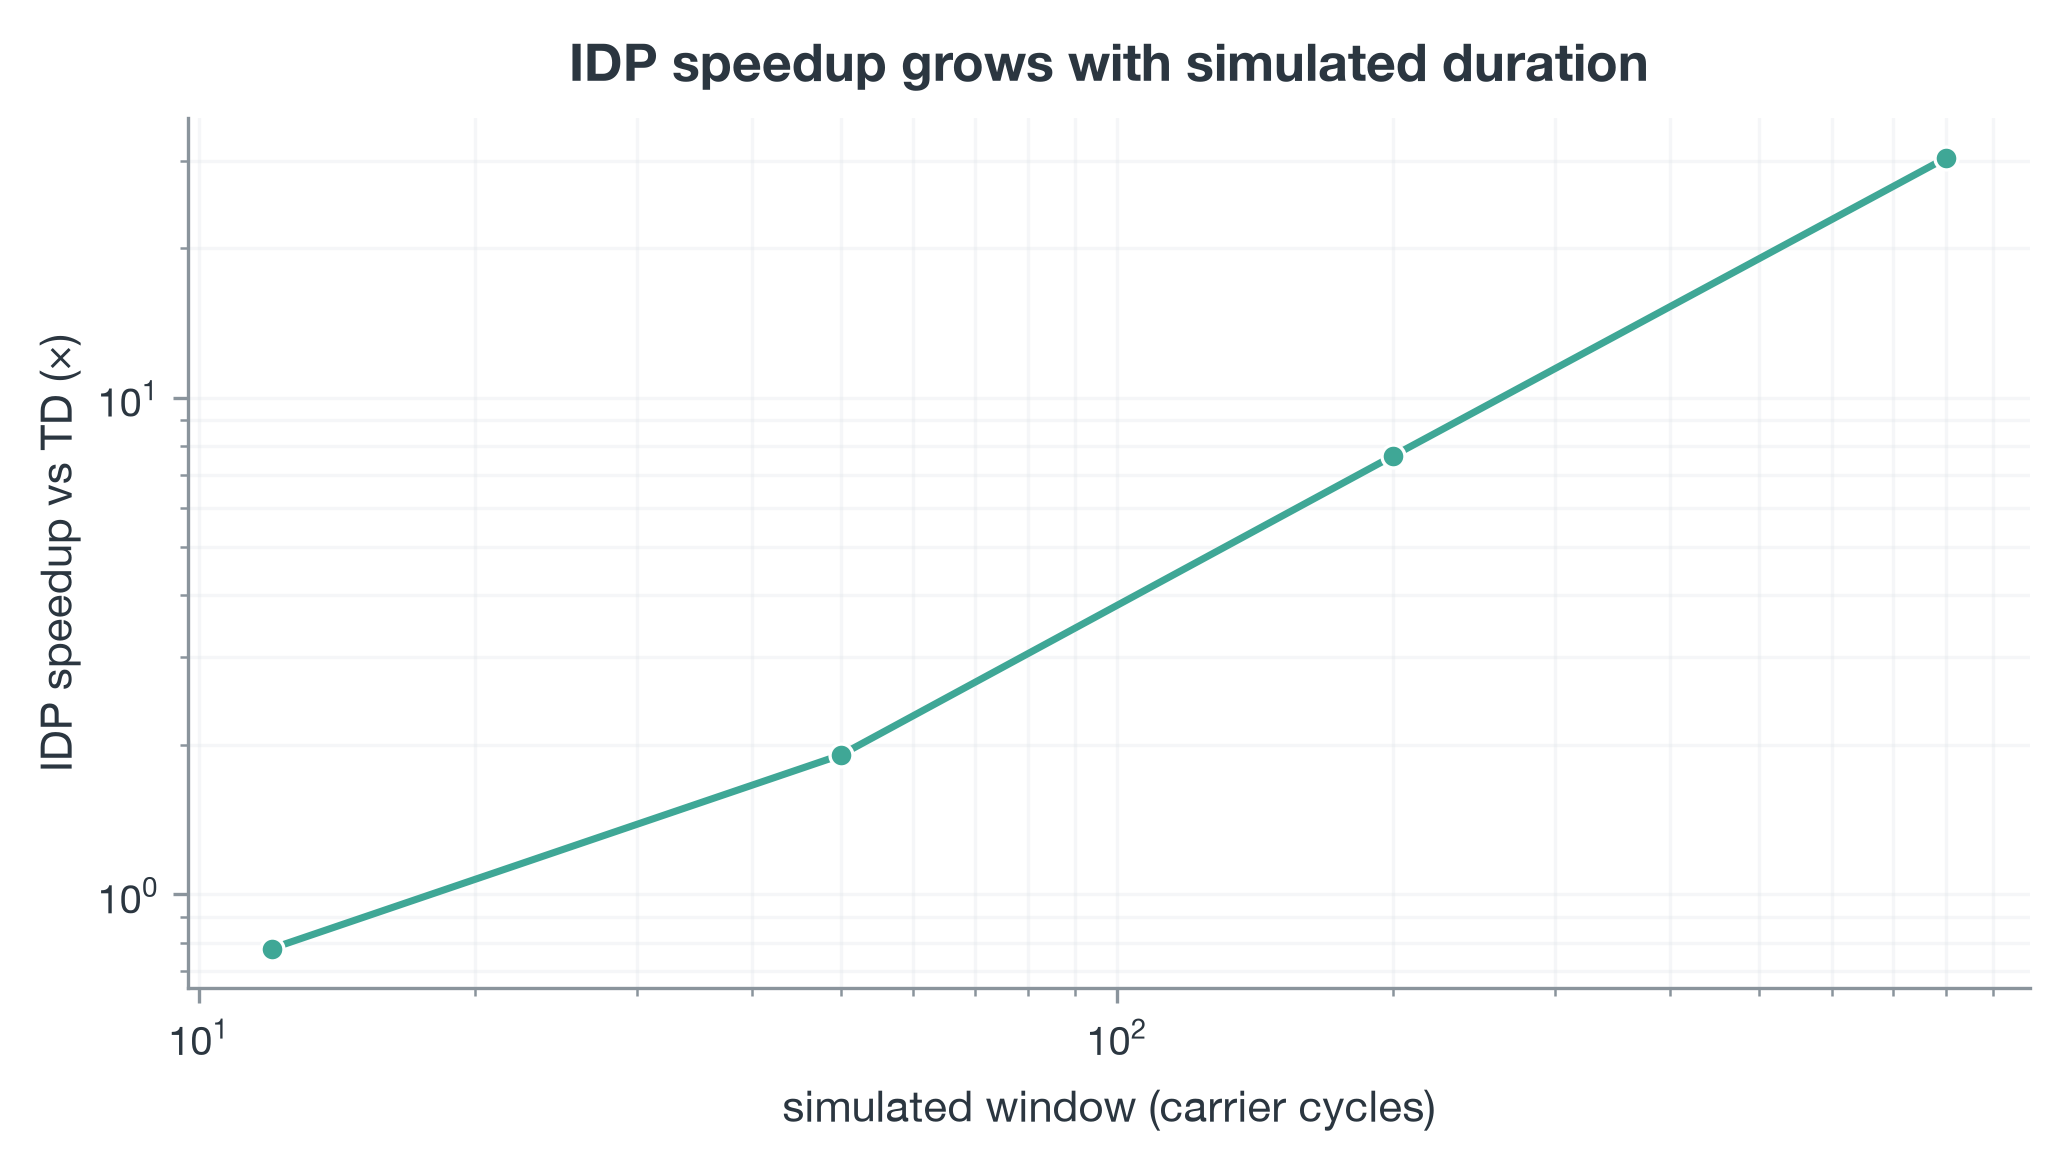

In [4]:
ns      = [r[0] for r in rows]
speedup = [r[3] for r in rows]

fig, ax = plt.subplots()
ax.plot(ns, speedup, "o-", color=PALETTE["teal"], mfc=PALETTE["teal"],
        mec="white", mew=0.8)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("simulated window (carrier cycles)")
ax.set_ylabel("IDP speedup vs TD (×)")
ax.set_title("IDP speedup grows with simulated duration")
ax.grid(True, which="both", alpha=0.3); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()


The short-horizon agreement is excellent and the speedup climbs steadily with
the simulated window. (Over very long horizons the two solvers slowly drift in
phase, so the envelope NRMSE grows - that is documented honestly in
`PAPER_CODE_MISMATCHES.md`.)